In [2]:
import time
import random
import matplotlib.pyplot as plt
import copy
import functools
import turtle
import random

№ 1 <br/>
(2 балла) <br/>
Реализуйте или найдите реализации двух сортировок: сортировка выбором и быстрая
сортировка. Проведите вычислительные эксперименты и нарисуйте графики,
показывающие зависимость времени выполнения двух алгоритмов от размера входных
данных. Рассмотрите три варианта входных данных:
1. Список случайных чисел
2. Отсортированный список
3. Отсортированный в обратную сторону список
Для каждого из вариантов должен быть свой график зависимости.

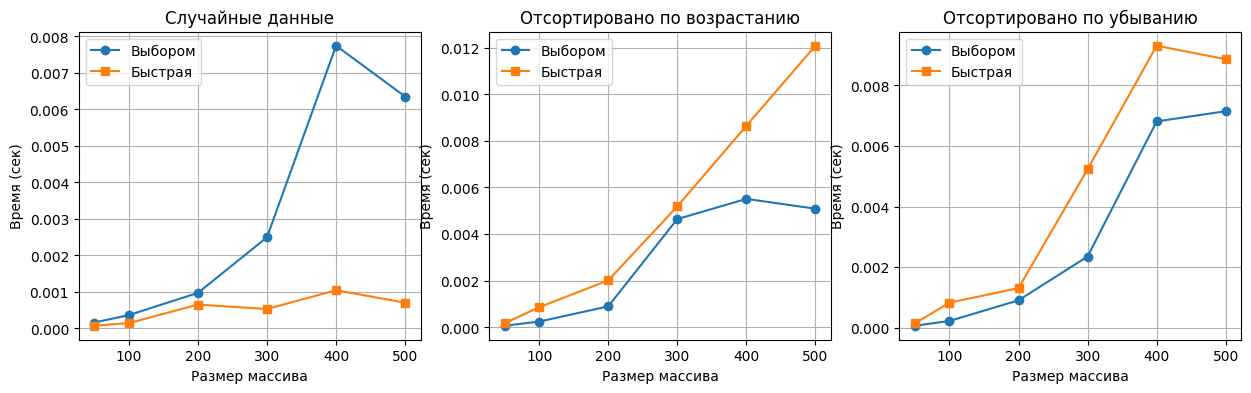

In [3]:
def selection_sort(arr):
    n = len(arr)
    for i in range(n):
        min_idx = i
        for j in range(i + 1, n):
            if arr[j] < arr[min_idx]:
                min_idx = j
        arr[i], arr[min_idx] = arr[min_idx], arr[i]
    return arr

def quick_sort(arr):
    if len(arr) <= 1:
        return arr
    pivot = arr[0]
    left = [x for x in arr[1:] if x < pivot]
    right = [x for x in arr[1:] if x >= pivot]
    return quick_sort(left) + [pivot] + quick_sort(right)

def measure_time(sort_func, data):
    data_copy = copy.deepcopy(data)
    start = time.perf_counter()
    if sort_func == selection_sort:
        sort_func(data_copy)
    else:
        sort_func(data_copy)
    return time.perf_counter() - start

sizes = [50, 100, 200, 300, 400, 500]

rand_sel, rand_quick = [], []
asc_sel, asc_quick = [], []
desc_sel, desc_quick = [], []

for n in sizes:
    rand_data = [random.randint(1, 1000) for _ in range(n)]
    rand_sel.append(measure_time(selection_sort, rand_data))
    rand_quick.append(measure_time(quick_sort, rand_data))
    
    asc_data = list(range(n))
    asc_sel.append(measure_time(selection_sort, asc_data))
    asc_quick.append(measure_time(quick_sort, asc_data))

    desc_data = list(range(n, 0, -1))
    desc_sel.append(measure_time(selection_sort, desc_data))
    desc_quick.append(measure_time(quick_sort, desc_data))

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(sizes, rand_sel, label='Выбором', marker='o')
plt.plot(sizes, rand_quick, label='Быстрая', marker='s')
plt.title('Случайные данные')
plt.xlabel('Размер массива')
plt.ylabel('Время (сек)')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(sizes, asc_sel, label='Выбором', marker='o')
plt.plot(sizes, asc_quick, label='Быстрая', marker='s')
plt.title('Отсортировано по возрастанию')
plt.xlabel('Размер массива')
plt.ylabel('Время (сек)')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(sizes, desc_sel, label='Выбором', marker='o')
plt.plot(sizes, desc_quick, label='Быстрая', marker='s')
plt.title('Отсортировано по убыванию')
plt.xlabel('Размер массива')
plt.ylabel('Время (сек)')
plt.legend()
plt.grid(True)

plt.show()

№ 2 <br/>
(2 балла) <br/>
Ряд Трибоначчи начинается с тройки 0, 0, 1, а каждое следующее число равно сумме
трёх предыдущих. Числа нумеруются с 0.
Напишите функцию tribonacci(n), которая принимает в себя номер числа и
возвращает n-ое число Трибоначчи. Функция должна быть рекурсивной.
При решении данной задачи не используйте циклы.
Укажите базовый и рекурсивный случаи функции.

In [ ]:
def tribonacci(n):
    if n == 0:
        return 0
    if n == 1:
        return 0
    if n == 2:
        return 1
    else:
        return tribonacci(n-1) + tribonacci(n-2) + tribonacci(n-3)

if __name__ == "__main__":
    print(tribonacci(0))
    print(tribonacci(1))
    print(tribonacci(2))
    print(tribonacci(3))
    print(tribonacci(4))
    print(tribonacci(5))
    print(tribonacci(6))
    print(tribonacci(7))
    print(tribonacci(8))
    print(tribonacci(9))

0
0
1
1
2
4
7
13
24
44


№ 3 <br/>
(2 балла) <br/>
Для задачи вашего варианта напишите подходящую рекурсивную функцию.
При решении задачи не используйте циклы.
Укажите базовый и рекурсивный случаи вашей функции.

1 вариант <br/>
Дано слово, состоящее только из строчных латинских букв. Проверьте, является ли
это слово палиндромом. Напишите рекурсивную функцию recursive_poly(word). В качестве
результата работы она должна возвращать строки «YES» или «NO». При решении нельзя
использовать срезы с шагом, отличным от 1.

In [ ]:
def recursive_poly(word):
    # Базовые случаи
    if len(word) <= 1:
        return "YES"
    if word[0] != word[-1]:
        return "NO"
    
    # Рекурсивный случай
    return recursive_poly(word[1:-1])

if __name__ == "__main__":
    print(recursive_poly("АБОБА"))
    print(recursive_poly("АБОБКИН"))

YES
NO


№ 4 <br/>
(2 балла) <br/>
    Числа Фибоначчи - это последовательность, которая вычисляется по рекуррентному
соотношению FN = FN - 1 + FN - 2, где F0 = 0, а F1 = 1. Числа Люка задаются примерно так же:
LN = LN - 1 + LN - 2, где L0 = 2, а L1 = 1. Пользуясь стандартным рекурсивным подходом,
напишите две функции - fibonacci(n) и lucas(n), которые будут вычислять n-е число
Фибоначчи и Люка соответственно. Измерьте время, которое требуется для вычисления FN
и LN вплоть до N = 40. Если ваш компьютер достаточно быстрый, N стоит увеличить для
повышения точности, а если слишком медленный - уменьшить, чтобы измерения
заканчивались за приемлемое время. <br/>
    Затем напишите функцию fib_with_lucas(n) и вспомогательную к ней,
lucas_with_fib(n), пользуясь такими свойствами этих последовательностей: <br/>
    • fib_with_lucas(n) – если поделить n нацело пополам и взять i = n // 2, а j = n - i, то
    Fn = Fi + j = (Fi + Lj) (Fj + Li) // 2; <br/>
    • lucas_with_fib(n) – в свою очередь, LN = FN - 1+FN + 1. <br/>
Сравните быстродействие fibonacci() и fib_with_lucas(). Постройте график.

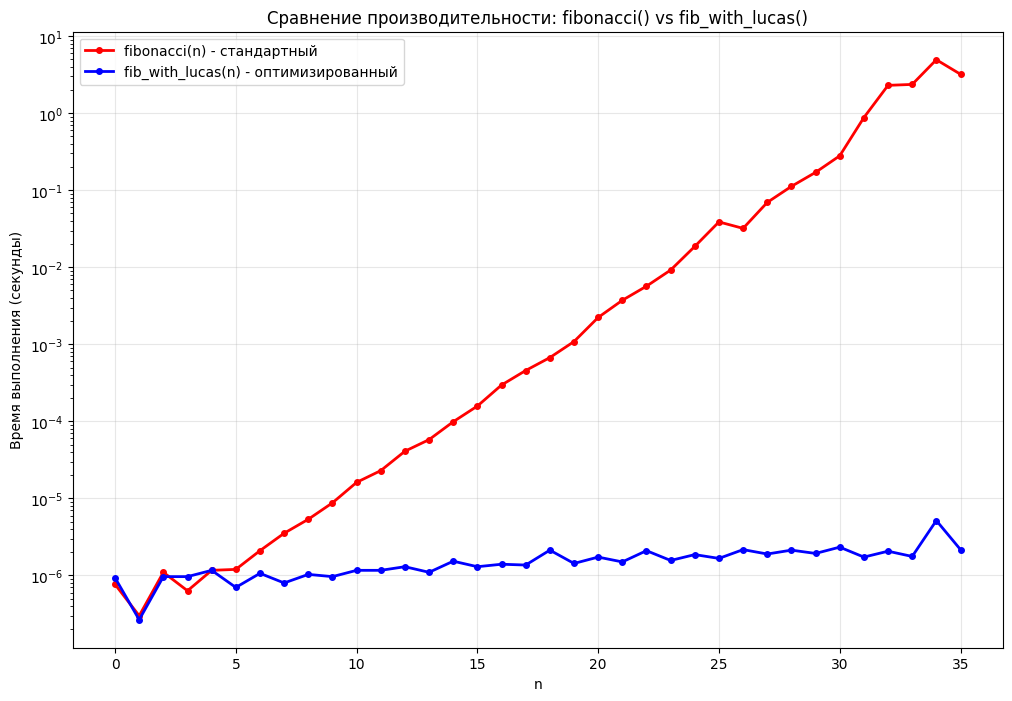

In [ ]:
def fibonacci(n):
    if n == 0:
        return 0
    if n == 1:
        return 1
    else:
        return fibonacci(n-1) + fibonacci(n-2)

def lucas(n):
    if n == 0:
        return 2
    if n == 1:
        return 1
    else:
        return lucas(n-1) + lucas(n-2)

@functools.lru_cache(maxsize=None)
def fib_with_lucas(n):
    if n == 0:
        return 0
    elif n == 1:
        return 1
    
    if n % 2 == 0:
        k = n // 2
        return fib_with_lucas(k) * lucas_with_fib(k)
    else:
        k = n // 2
        fk = fib_with_lucas(k)
        fk1 = fib_with_lucas(k + 1)
        return fk1 * fk1 + fk * fk

@functools.lru_cache(maxsize=None) 
def lucas_with_fib(n):
    if n == 0:
        return 2
    if n == 1:
        return 1
    
    return fib_with_lucas(n-1) + fib_with_lucas(n+1)

def timing_func(func, n):
    start_time = time.perf_counter()
    result = func(n)
    end_time = time.perf_counter()
    return end_time - start_time

N = 35
TRIALS = 3

n_values = list(range(N+1))
times_fib = []

for n in n_values:
    times = []
    for _ in range(TRIALS):
        time_taken = timing_func(fibonacci, n)
        times.append(time_taken)
    avg_time = sum(times) / len(times)
    times_fib.append(avg_time)

times_fib_with_lucas = []

for n in n_values:
    fib_with_lucas.cache_clear()
    lucas_with_fib.cache_clear()
    
    times = []
    for _ in range(TRIALS):
        time_taken = timing_func(fib_with_lucas, n)
        times.append(time_taken)
    avg_time = sum(times) / len(times)
    times_fib_with_lucas.append(avg_time)

plt.figure(figsize=(12, 8))
plt.plot(n_values, times_fib, 'ro-', label='fibonacci(n) - стандартный', linewidth=2, markersize=4)
plt.plot(n_values, times_fib_with_lucas, 'bo-', label='fib_with_lucas(n) - оптимизированный', linewidth=2, markersize=4)

plt.xlabel('n')
plt.ylabel('Время выполнения (секунды)')
plt.title('Сравнение производительности: fibonacci() vs fib_with_lucas()')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()


№ 5 <br/>
(3 балла) <br/>
Хорошим примером для иллюстрации рекурсивных алгоритмов являются задачи
рисования фракталов. Далее представлена программа, которая при помощи модуля turtle
(turtle — Turtle graphics — Python 3.9.7 documentation) рисует фрактальное дерево.
```
import turtle
def tree(branchLen, t):
 if branchLen > 5:
 t.forward(branchLen)
 t.right(20)
 tree(branchLen - 15, t)
 t.left(40)
 tree(branchLen - 15, t)
 t.right(20)
 t.backward(branchLen)
def main():
 t = turtle.Turtle()
 myWin = turtle.Screen()
 t.left(90)
 t.up()
 t.backward(100)
 t.down()
 t.color("green")
 tree(75, t)
 myWin.exitonclick()
main()
```
Запустите программу и разберитесь в ее коде. Попробуйте поменять параметры при вызове
функции tree и внутри нее.
Последовательно измените программу для рисования рекурсивного дерева по следующим
пунктам:
1. Измените толщину ветвей, чтобы при уменьшении branchLen линии становились
тоньше.
2. Измените цвет ветвей таким образом, чтобы самые короткие ветви окрашивались
как листья.
3. Измените угол поворота черепахи, чтобы каждая ветвь поворачивалась
произвольным образом в некотором диапазоне. Например, выбирайте угол между
15-ю и 45-ю градусами. Поэкспрериментируйте в поисках лучшего вида.
4. Измените рекурсивную часть branchLen, чтобы каждый раз вычиталось
произвольное значение из некоторого диапазона вместо некой постоянной
величины.
В отчете приведите несколько примеров получившихся деревьев. 

In [ ]:
def tree(branchLen, t, thickness):
    if branchLen > 5:
        t.pensize(thickness)
        
        if branchLen < 15:
            t.color("green")
        elif branchLen < 25:
            t.color("lightgreen")
        else:
            t.color("saddlebrown")
        
        t.forward(branchLen)
        
        angle = random.randint(15, 45)
        
        reduction = random.randint(10, 20)
        
        t.right(angle)
        new_thickness = max(1, thickness * 0.7)
        tree(branchLen - reduction, t, new_thickness)
        
        t.left(2 * angle)
        tree(branchLen - reduction, t, new_thickness)
        
        t.right(angle)
        t.backward(branchLen)
        t.pensize(thickness)
        if branchLen >= 25:
            t.color("saddlebrown")
    else:
        t.color("green")
        t.pensize(1)
        t.forward(branchLen)
        t.backward(branchLen)

def main():
    t = turtle.Turtle()
    myWin = turtle.Screen()
    myWin.bgcolor("white")
    myWin.title("Фрактальное дерево")
    
    t.speed(0)
    t.left(90)
    t.up()
    t.backward(150)
    t.down()
    
    tree(80, t, 8)
    
    myWin.exitonclick()

if __name__ == "__main__":
    main()

№ 6 <br/>
(3 балла) <br/>
При помощи модуля turtle нарисуйте фрактал, указанный в вашем варианте (материалы
Рекурсия: фракталы (mipt-cs.github.io)). <br/>
Вариант 1. Кривая Коха.

In [ ]:
def koch_curve(t, length, depth):
    if depth == 0:
        t.forward(length)
    else:
        new_length = length / 3
        koch_curve(t, new_length, depth - 1)
        t.left(60)
        koch_curve(t, new_length, depth - 1)
        t.right(120)
        koch_curve(t, new_length, depth - 1)
        t.left(60)
        koch_curve(t, new_length, depth - 1)

screen = turtle.Screen()
screen.setup(width=800, height=400)
screen.bgcolor("white")
screen.title("Кривая Коха")

t = turtle.Turtle()
t.speed(0)
t.penup()
t.goto(-300, 0)
t.pendown()

depth = 4
koch_curve(t, 600, depth)

t.hideturtle()
screen.exitonclick()

№ 7 <br/>
(3 балла) <br/>
Найдите или придумайте алгоритм для рисования фрактальных гор. Подсказка: одним
из возможных методов будет использование треугольников.

In [ ]:
def draw_fractal_mountain(t, x1, y1, x2, y2, roughness, depth):
    if depth == 0 or abs(x2 - x1) < 2:
        t.penup()
        t.goto(x1, y1)
        t.pendown()
        t.goto(x2, y2)
        return

    x_mid = (x1 + x2) / 2
    y_mid = (y1 + y2) / 2
    y_mid += random.uniform(-roughness, roughness)

    draw_fractal_mountain(t, x1, y1, x_mid, y_mid, roughness / 2, depth - 1)
    draw_fractal_mountain(t, x_mid, y_mid, x2, y2, roughness / 2, depth - 1)

screen = turtle.Screen()
screen.setup(width=800, height=400)
screen.title("Фрактальные горы")

t = turtle.Turtle()
t.speed(0)

x_start, y_start = -350, -100
x_end, y_end = 350, -100

initial_roughness = 100
max_depth = 6

draw_fractal_mountain(t, x_start, y_start, x_end, y_end, initial_roughness, max_depth)

t.hideturtle()
screen.exitonclick()


№ 8 <br/>
(3 балла) <br/>
Решите рекурсивно мини-судоку размером 4x4. Для этого напишите функцию
solve_sudoku(matrix), где matrix - целочисленная матрица (список списков).
В мини-судоку числа от 1 до 4 встречаются ровно один раз в каждой вертикали и
горизонтали, а также в квадратах 2x2. <br/>
Укажите базовый и рекурсивный случаи вашего алгоритма. <br/>
Судоку представлено в виде таблицы чисел, в которой нулями обозначены пустые
места: <br/>
0000 <br/>
0020 <br/>
0100 <br/>
3004 <br/>
Правильный ответ: <br/>
2341 <br/>
1423 <br/>
4132 <br/>
3214 <br/>

In [ ]:
def solve_sudoku(matrix):
    for row in range(4):
        for col in range(4):
            if matrix[row][col] == 0:
                for num in range(1, 5):
                    if is_valid(matrix, row, col, num):
                        matrix[row][col] = num
                        if solve_sudoku(matrix):
                            return True
                        matrix[row][col] = 0
                return False
    return True


def is_valid(matrix, row, col, num):
    for c in range(4):
        if matrix[row][c] == num:
            return False

    for r in range(4):
        if matrix[r][col] == num:
            return False

    start_row = (row // 2) * 2
    start_col = (col // 2) * 2
    for r in range(start_row, start_row + 2):
        for c in range(start_col, start_col + 2):
            if matrix[r][c] == num:
                return False

    return True


if __name__ == "__main__":
    sudoku = [
        [0, 0, 0, 0],
        [0, 0, 2, 0],
        [0, 1, 0, 0],
        [3, 0, 0, 4]
    ]

    print("Исходное судоку:")
    for row in sudoku:
        print(''.join(map(str, row)))

    if solve_sudoku(sudoku):
        print("\nРешённое судоку:")
        for row in sudoku:
            print(''.join(map(str, row)))
    else:
        print("Решение не найдено")

Исходное судоку:
0000
0020
0100
3004

Решённое судоку:
2341
1423
4132
3214
